# EDA Notebook

We will use this notebook to evaluate and process our data from the CSV files.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
def load_data(filepath):
    return pd.read_csv(filepath)

# Import CSV files into pandas

We will import the csv from the `data/raw/smart_city_csvs` folder.

In [3]:
city_df = load_data('../data/raw/smart_city_csvs/city_traffic_accidents.csv')

urban_df = load_data('../data/raw/smart_city_csvs/urbanpulse_311_complaints.csv')


# City Traffic Data

This part of the notebook will cover the features and data around the `city_traffic_accidents.csv` file.

In [4]:
city_df.head(10)

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1784167,Source2,2,2019-10-29 13:16:54,2019-10-29 15:21:34,35.834797,-78.638512,NaN,NaN,0.000,...,False,False,False,False,False,False,Day,Day,Day,Day
1,A-862811,Source2,2,2021-10-13 06:30:00,2021-10-13 06:59:15,36.088970,-96.011734,NaN,NaN,0.000,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-4054572,Source1,2,2022-08-14 14:42:58,2022-08-14 16:27:58,33.537049,-86.794445,33.535373,-86.796156,0.152,...,False,False,False,False,False,False,Day,Day,Day,Day
3,A-6147589,Source1,2,2021-06-25 19:13:44,2021-06-25 20:42:30,34.071722,-117.612886,34.078917,-117.625339,0.869,...,False,False,False,False,False,False,Day,Day,Day,Day
4,A-5025169,Source1,2,2022-03-18 12:50:30,2022-03-18 13:13:00,40.324235,-76.790464,40.322625,-76.788114,0.166,...,False,False,False,False,False,False,Day,Day,Day,Day
5,A-4007360,Source1,2,2022-11-16 05:22:30.000000,2022-11-16 08:04:30.000000,34.024005,-117.557851,34.029942,-117.579011,1.279,...,False,False,False,False,False,False,Night,Night,Night,Day
6,A-2185422,Source2,2,2019-04-24 07:25:21,2019-04-24 08:25:01,34.136070,-80.880547,NaN,NaN,0.000,...,False,False,False,False,True,False,Day,Day,Day,Day
7,A-94012,Source2,2,2016-08-31 11:14:13,2016-08-31 11:44:13,34.245651,-118.874870,NaN,NaN,0.000,...,False,False,False,False,False,False,Day,Day,Day,Day
8,A-6717568,Source1,2,2020-10-24 20:15:00,2020-10-24 22:19:12,38.671507,-120.566459,38.671875,-120.566081,0.033,...,False,False,False,False,False,False,Night,Night,Night,Night
9,A-2960129,Source2,2,2018-03-21 20:44:14,2018-03-21 21:14:06,30.413244,-97.690582,NaN,NaN,0.000,...,False,False,False,False,True,False,Night,Night,Night,Day


In [5]:
print(city_df.shape)

(500000, 46)


In [6]:
city_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     500000 non-null  object 
 1   Source                 500000 non-null  object 
 2   Severity               500000 non-null  int64  
 3   Start_Time             500000 non-null  object 
 4   End_Time               500000 non-null  object 
 5   Start_Lat              500000 non-null  float64
 6   Start_Lng              500000 non-null  float64
 7   End_Lat                280022 non-null  float64
 8   End_Lng                280022 non-null  float64
 9   Distance(mi)           500000 non-null  float64
 10  Description            500000 non-null  object 
 11  Street                 499346 non-null  object 
 12  City                   499972 non-null  object 
 13  County                 500000 non-null  object 
 14  State                  500000 non-nu

In [7]:
city_df.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,500000.000000,500000.000000,500000.000000,280022.000000,280022.000000,500000.000000,489300.000000,370812.000000,488629.000000,490830.000000,488518.000000,463098.000000,357634.000000
mean,2.212386,36.205450,-94.706816,36.269349,-95.712652,0.558359,61.657263,58.223946,64.802873,29.536751,9.090389,7.689107,0.008308
std,0.487531,5.076753,17.383787,5.269770,18.096908,1.719821,19.013075,22.385876,22.857251,1.007469,2.703371,5.283195,0.104710
min,1.000000,24.555269,-124.497585,24.571240,-124.497421,0.000000,-89.000000,-89.000000,1.000000,0.120000,0.000000,0.000000,0.000000
25%,2.000000,33.400517,-117.217072,33.461970,-117.747945,0.000000,49.000000,43.000000,48.000000,29.370000,10.000000,4.600000,0.000000
50%,2.000000,35.831195,-87.792388,36.191048,-88.022662,0.029000,64.000000,62.000000,67.000000,29.860000,10.000000,7.000000,0.000000
75%,2.000000,40.081910,-80.351962,40.176147,-80.243654,0.462000,76.000000,75.000000,84.000000,30.030000,10.000000,10.400000,0.000000
max,4.000000,48.993996,-67.113167,48.995141,-67.109242,138.910004,136.400000,136.000000,100.000000,58.630000,100.000000,131.000000,10.020000


In [8]:
# List all headers in the city_df DataFrame
print(city_df.columns)

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')


In [9]:
city_df['State'].value_counts()

State
CA    112305
FL     56897
TX     37858
SC     24270
NY     22493
NC     21975
VA     19574
PA     19300
MN     12261
OR     11668
AZ     11196
GA     10985
IL     10882
TN     10881
MI     10535
LA      9709
MD      9202
NJ      9095
OH      7610
WA      7072
AL      6555
UT      6315
CO      5945
OK      5484
MO      5047
CT      4534
IN      4398
MA      3981
WI      2269
KY      2114
MT      1885
NE      1791
IA      1755
AR      1504
KS      1366
NV      1351
DC      1255
RI      1101
MS       969
DE       895
WV       893
ID       744
NH       676
NM       660
ND       249
WY       245
ME       186
VT        44
SD        21
Name: count, dtype: int64

In [ ]:
city_df['hour'] = city_df['Start_Time']

In [10]:
def check_data_quality(df, id_column='ID'):
    # I am returning a dictionary with the data quality results.
    return {
        'total_rows': df.shape[0],
        'total_columns': df.shape[1],
        'missing_by_column': df.isnull().sum().to_dict(),
        'total_missing': df.isnull().sum().sum(),
        'duplicate_count': df.duplicated(subset=[id_column]).sum(),
        'data_types': df.dtypes.apply(lambda x: x.name).to_dict()
    }

In [11]:
df_quality_report = check_data_quality(city_df)

for col, count in df_quality_report['missing_by_column'].items():
    if count > 0:
        print(f"  - {col}: {count}")

  - End_Lat: 219978
  - End_Lng: 219978
  - Street: 654
  - City: 28
  - Zipcode: 118
  - Timezone: 476
  - Airport_Code: 1514
  - Weather_Timestamp: 7842
  - Temperature(F): 10700
  - Wind_Chill(F): 129188
  - Humidity(%): 11371
  - Pressure(in): 9170
  - Visibility(mi): 11482
  - Wind_Direction: 11382
  - Wind_Speed(mph): 36902
  - Precipitation(in): 142366
  - Weather_Condition: 11300
  - Sunrise_Sunset: 1561
  - Civil_Twilight: 1561
  - Nautical_Twilight: 1561
  - Astronomical_Twilight: 1561


In [21]:
all_dir = city_df['Wind_Direction'].unique().tolist()
# Exclude the following values: 'Calm', 'Variable', 'Unknown'
exclude_values = ['Calm', 'Variable', 'Unknown', 'VAR', 'CALM']
all_dir = [dir for dir in all_dir if dir not in exclude_values]
all_dir

['E',
 'S',
 'W',
 'ENE',
 'NNE',
 'SSW',
 'SSE',
 'NNW',
 'ESE',
 'SE',
 'N',
 'WSW',
 'SW',
 'North',
 'NW',
 'NE',
 'WNW',
 'East',
 nan,
 'West',
 'South']

In [ ]:
city_df['wind_dir_deg'] = city_df['Wind_Direction'].map({
    'N': 0,
    'North': 0,
    'NE': 45,
    'NNE': 22.5,
    'NNW': 337.5,
    'E': 90,
    'ENE': 67.5,
    'East': 90,
    'ESE': 112.5,
    'SE': 135,
    'S': 180,
    'South': 180,
    'SW': 225,
    'SSW': 202.5,
    'SSE': 157.5,
    'W': 270,
    'West': 270,
    'WNW': 292.5,
    'WSW': 247.5,
    'NW': 315
})

mean_degrees = city_df['wind_dir_deg'].mean()
mean_degrees

np.float64(177.23483730344896)

In [27]:
# Convert Weather_Condition to a numerical value
all_cond = city_df['Weather_Condition'].unique().tolist()
city_df['weather_cond_num'] = city_df['Weather_Condition'].map({
    'Mostly Cloudy': 0,
    'Light Rain with Thunder': 3,
    'Fair': 0,
    'Clear': 0,
    'Overcast': 0,
    'Cloudy': 0,
    'Scattered Clouds': 0,
    'Light Snow': 1,
    'Partly Cloudy': 0,
    'T-Storm': 3,
    'Heavy Snow': 2,
    'Light Rain': 1,
    'Smoke': 1,
    'Fog': 2,
    'Fair / Windy': 0,
    'Light Drizzle': 1,
    'Drizzle': 1,
    'Haze': 1,
    'Rain': 2,
    'Heavy Rain': 3,
    'T-Storm / Windy': 3,
    'Thunder in the Vicinity': 1,
    'Snow': 2,
    'Heavy Drizzle': 2,
    'Light Thunderstorms and Rain': 3,
    'Cloudy / Windy': 0,
    'Wintry Mix': 2,
    'N/A Precipitation': 0,
    'Thunder': 1,
    'Light Snow / Windy': 1,
    'Heavy Snow / Windy': 2,
    'Light Rain / Windy': 1,
    'Patches of Fog': 2,
    'Heavy Rain / Windy': 3,
    'Heavy Thunderstorms and Rain': 3,
    'Mostly Cloudy / Windy': 0,
    'Heavy T-Storm': 3,
    'Mist': 2,
    'Partly Cloudy / Windy': 0,
    'Shallow Fog': 2,
    'Snow / Windy': 2,
    'Blowing Snow': 2,
    'Thunderstorm': 3,
    'Haze / Windy': 1,
    'Freezing Rain': 2,
    'Blowing Snow / Windy': 2,
    'Rain / Windy': 2,
    'Showers in the Vicinity': 0,
    'Light Freezing Rain': 1,
    'Snow and Sleet': 2,
    'Widespread Dust': 1,
    'Snow and Sleet / Windy': 2,
    'Thunderstorms and Rain': 3,
    'Light Freezing Drizzle': 1,
    'Fog / Windy': 2,
    'Heavy T-Storm / Windy': 3,
    'Light Freezing Fog': 1,
    'Ice Pellets': 2,
    'Tornado': 3,
    'Light Thunderstorms and Snow': 3,
    'Light Rain Shower': 1,
    'Drizzle and Fog': 2,
    'Blowing Dust / Windy': 1,
    'Heavy Sleet': 2,
    'Blowing Dust': 1,
    'Light Drizzle / Windy': 1,
    'Light Freezing Rain / Windy': 1,
    'Wintry Mix / Windy': 2,
    'Thunder / Windy': 1,
    'Hail': 2,
    'Light Snow and Sleet': 2,
    'Light Rain Showers': 1,
    'Smoke / Windy': 1,
    'Light Ice Pellets': 1,
    'Snow and Thunder': 3,
    'Sleet': 2,
    'Small Hail': 2,
    'Sleet / Windy': 2,
    'Light Snow with Thunder': 3,
    'Widespread Dust / Windy': 1,
    'Duststorm': 1,
    'Sand / Dust Whirlwinds': 1,
    'Light Rain Shower / Windy': 1,
    'Light Snow and Sleet / Windy': 2,
    'Rain Showers': 2,
    'Light Snow Shower': 1,
    'Freezing Drizzle': 2,
    'Light Snow Showers': 1,
    'Thunder / Wintry Mix': 2,
    'Rain Shower': 2,
    'Squalls': 2,
    'Drifting Snow / Windy': 2,
    'Mist / Windy': 2,
    'Sand / Dust Whirls Nearby': 1,
    'Light Snow Grains': 1,
    'Sand': 1,
    'Light Sleet': 1,
    'Partial Fog': 2,
    'Drizzle / Windy': 1,
    'Patches of Fog / Windy': 2,
    'Thunder / Wintry Mix / Windy': 2,
    'Light Sleet / Windy': 1,
    'Squalls / Windy': 2,
    'Heavy Freezing Drizzle': 2,
    'Snow Grains': 2,
    'Shallow Fog / Windy': 1})
city_df['weather_cond_num'].value_counts()

weather_cond_num
0.0    425076
1.0     42596
2.0     15271
3.0      5757
Name: count, dtype: int64

In [28]:
all_target_values = city_df['Severity'].value_counts()
all_target_values

Severity
2    398335
3     84063
4     13244
1      4358
Name: count, dtype: int64

In [29]:
# I need to check and make sure I do not have any empty values in any of my columns in the city_df DataFrame.

column_list = city_df.columns.tolist()
for col in column_list:
    missing_count = city_df[col].isnull().sum()
    if missing_count > 0:
        print(f"Column '{col}' has {missing_count} missing values.")


Column 'End_Lat' has 219978 missing values.
Column 'End_Lng' has 219978 missing values.
Column 'Street' has 654 missing values.
Column 'City' has 28 missing values.
Column 'Zipcode' has 118 missing values.
Column 'Timezone' has 476 missing values.
Column 'Airport_Code' has 1514 missing values.
Column 'Weather_Timestamp' has 7842 missing values.
Column 'Temperature(F)' has 10700 missing values.
Column 'Wind_Chill(F)' has 129188 missing values.
Column 'Humidity(%)' has 11371 missing values.
Column 'Pressure(in)' has 9170 missing values.
Column 'Visibility(mi)' has 11482 missing values.
Column 'Wind_Direction' has 11382 missing values.
Column 'Wind_Speed(mph)' has 36902 missing values.
Column 'Precipitation(in)' has 142366 missing values.
Column 'Weather_Condition' has 11300 missing values.
Column 'Sunrise_Sunset' has 1561 missing values.
Column 'Civil_Twilight' has 1561 missing values.
Column 'Nautical_Twilight' has 1561 missing values.
Column 'Astronomical_Twilight' has 1561 missing val

Text(0, 0.5, 'Count')

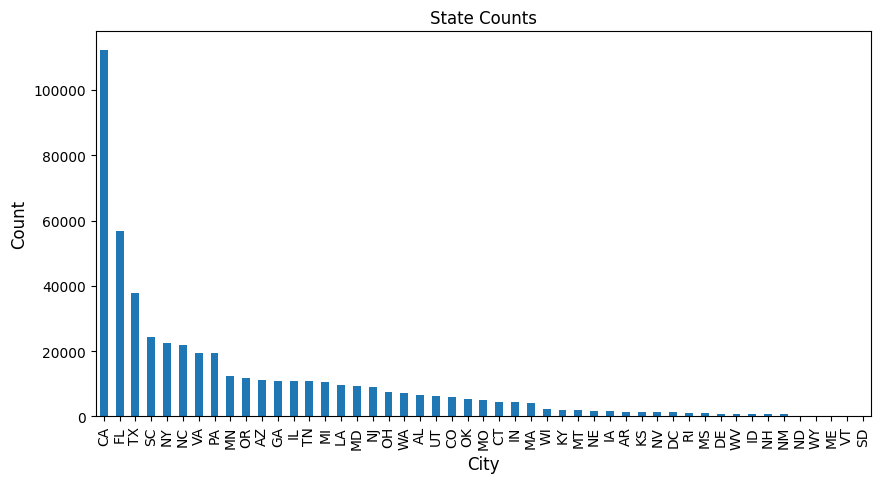

In [12]:
# Creating a bar chart of the product categories.
plt.figure(figsize=(10, 5))
plt.title("State Counts")

city_df['State'].value_counts().plot(kind='bar')
plt.xlabel("City", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Urban Data

This part of the notebook will show important features around the `urbanpulse_311_complaints.csv` file.

In [13]:
urban_df.head(10)

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,resolution_description,borough,open_data_channel_type,status
0,67874778,2026-02-06T14:57:28.000,2026-02-07T21:24:52.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,This complaint is a duplicate of a building-wi...,MANHATTAN,ONLINE,Closed
1,68207007,2026-03-04T10:40:04.000,2026-03-06T16:05:24.000,HPD,Department of Housing Preservation and Develop...,PLUMBING,WATER SUPPLY,HPD conducted an inspection of this complaint....,BRONX,ONLINE,Closed
2,68298021,2026-03-12T11:26:42.000,2026-03-12T12:34:47.000,NYPD,New York City Police Department,Illegal Parking,Posted Parking Sign Violation,The New York City Police Department responded ...,BROOKLYN,MOBILE,Closed
3,67870560,2026-02-06T23:51:20.000,2026-02-09T12:21:00.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,HPD responded to a complaint of no heat or hot...,MANHATTAN,ONLINE,Closed
4,67844971,2026-02-03T10:01:52.000,2026-02-03T10:55:36.000,NYPD,New York City Police Department,Illegal Parking,Blocked Crosswalk,The New York City Police Department responded ...,BROOKLYN,MOBILE,Closed
5,68173650,2026-03-01T13:18:50.000,2026-03-01T13:41:16.000,NYPD,New York City Police Department,Illegal Parking,Posted Parking Sign Violation,The New York City Police Department responded ...,BROOKLYN,ONLINE,Closed
6,67996182,2026-02-14T04:34:09.000,2026-02-14T07:30:31.000,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,The New York City Police Department responded ...,BROOKLYN,MOBILE,Closed
7,67989111,2026-02-13T13:14:39.000,2026-02-15T21:30:43.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,APARTMENT ONLY,This complaint is a duplicate of a building-wi...,QUEENS,ONLINE,Closed
8,68284021,2026-03-10T08:15:03.000,2026-03-11T14:26:55.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,HPD responded to a complaint of no heat or hot...,MANHATTAN,ONLINE,Closed
9,67918125,2026-02-09T11:41:22.000,NaN,DOHMH,Department of Health and Mental Hygiene,Non-Residential Heat,Inadequate or No Heat,The Department of Health and Mental Hygiene ha...,BRONX,ONLINE,In Progress


In [14]:
print(urban_df.shape)

(434722, 11)


In [15]:
urban_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 434722 entries, 0 to 434721
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   unique_key              434722 non-null  int64 
 1   created_date            434722 non-null  object
 2   closed_date             384642 non-null  object
 3   agency                  434722 non-null  object
 4   agency_name             434722 non-null  object
 5   complaint_type          434722 non-null  object
 6   descriptor              431047 non-null  object
 7   resolution_description  434722 non-null  object
 8   borough                 434722 non-null  object
 9   open_data_channel_type  434722 non-null  object
 10  status                  434722 non-null  object
dtypes: int64(1), object(10)
memory usage: 36.5+ MB


In [29]:
# Show all categories in the urban_df DataFrame
print(urban_df.columns)
urban_df_quality_report = check_data_quality(urban_df, id_column='unique_key')
for col, count in urban_df_quality_report['missing_by_column'].items():
    if count > 0:
        print(f"  - {col}: {count}")

Index(['unique_key', 'created_date', 'closed_date', 'agency', 'agency_name',
       'complaint_type', 'descriptor', 'resolution_description', 'borough',
       'open_data_channel_type', 'status'],
      dtype='object')
  - closed_date: 50080
  - descriptor: 3675


In [24]:
urban_df['agency'].value_counts()

agency
NYPD     163498
HPD      127848
DSNY      51482
DOT       38642
DEP       20719
DOB       11126
DPR        7178
DOHMH      6455
TLC        3228
DHS        2279
DCWP       1915
DOE         328
OTI          17
OOS           7
Name: count, dtype: int64

In [25]:
urban_df['borough'].value_counts()

borough
BROOKLYN         132549
QUEENS           106203
BRONX             92354
MANHATTAN         77788
STATEN ISLAND     25487
Unspecified         341
Name: count, dtype: int64

In [26]:
urban_df['complaint_type'].value_counts()

complaint_type
Illegal Parking                   66159
HEAT/HOT WATER                    64362
Noise - Residential               38931
Snow or Ice                       27453
Blocked Driveway                  24920
                                  ...  
Illegal Animal Sold                   2
Found Property                        1
Building Marshal's Office             1
Institution Disposal Complaint        1
Dept of Investigations                1
Name: count, Length: 151, dtype: int64

Text(0, 0.5, 'Count')

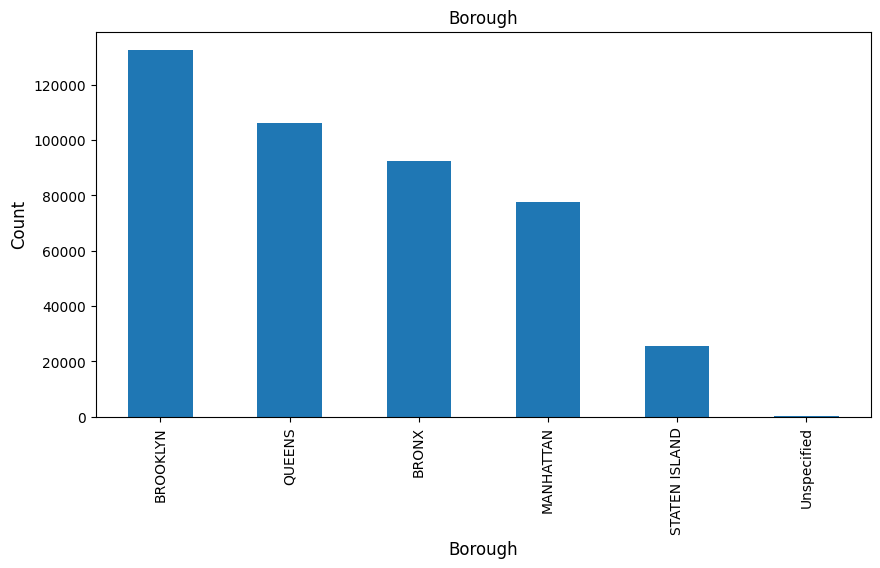

In [34]:
# Creating a bar chart of the product categories.
plt.figure(figsize=(10, 5))
plt.title("Borough")

urban_df['borough'].value_counts().plot(kind='bar')
plt.xlabel("Borough", fontsize=12)
plt.ylabel("Count", fontsize=12)

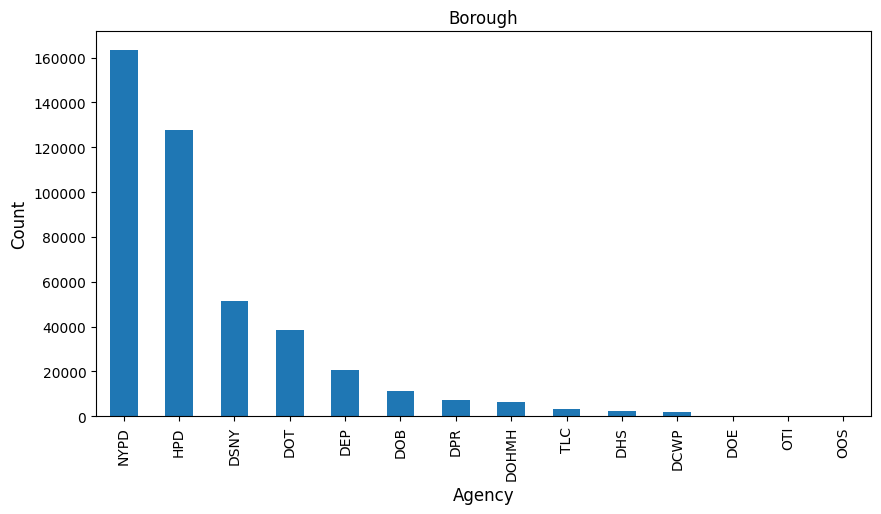

In [35]:
# Creating a bar chart of the product categories.
plt.figure(figsize=(10, 5))
plt.title("Borough")

urban_df['agency'].value_counts().plot(kind='bar')
plt.xlabel("Agency", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.show()